# Active Lives 2017-18 — London EDA & Multi-Pillar Analysis (Wave 3)

Same template as the 2015-16 / 2022-23 wave notebooks, **configured to what the diagnostics proved
about this wave** rather than to the baseline defaults.

**Verified differences for 2017-18:**

| Item | 2017-18 |
|---|---|
| Geography | `LA_2021`, **wave-specific map derived from this wave’s own `.sav`** |
| Borough codes | **4 codes swapped vs the shared map** (8⇄9 Barnet/Barking, 138⇉139 K&C/Islington) |
| Ethnicity | `Eth7` code 3 = **"South Asian"** (as 2016-17 / 2019-20) |
| Activity | code 2 = Active (middle band labelled "Insufficiently Active" — cosmetic only) |
| NS-SEC | 5 codes (incl. "Aged <16 or 75+") |
| Health | **absent** → dropped from the regression |
| Volunteering | present, **coded 0/1** (62.6% non-null) → Pillar 4 runs |
| Indoor/Outdoor | present, **31.9% rotation subgroup** → Pillar 3 runs, indicative base only |

> **Why the wave-specific map matters:** coverage on `LA_2021` was 1.000 with all 33 codes present —
> a coverage check passes cleanly — yet 4 codes mean *different boroughs* than the shared map claims.
> Using the shared map would have silently swapped Barnet with Barking and Dagenham. Coherence with
> the other waves is guaranteed through the **GSS code**, not the integer.


## 1. Load the pre-filtered London CSV

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV      = r"C:/Users/Lenovo/London-Sport-Forecasting-Patterns/data/processed/active_lives_london_y3_2017-18.csv"
SAV_2017 = r"C:\Users\Lenovo\London-Sport-Forecasting-Patterns\data\raw\active_lives_survey_nov_17-18_data_year_3_shared_20250103.sav"

df = pd.read_csv(CSV)
print("shape:", df.shape, "| year:", df["survey_year"].unique() if "survey_year" in df else "?")

shape: (15967, 527) | year: ['2017-18']


## 2. Codebook — decode numeric codes to labels

Verified against this wave's `.sav` value labels via `compare_codebooks`. Three wave-specific
codings: **Eth7[3] = "South Asian"**, the activity middle band is "Insufficiently Active"
(cosmetic — we target code 2 = Active), **NSSEC5 has a 5th code**, and **`VolAny` is 0/1** here
(not a labelled string), so it is decoded explicitly to match the `"Volunteered"` target used by
every other wave.

In [2]:
CODEBOOK = {
    "MEMS7GR_SPORTCOUNT_A01":     {0: "Inactive", 1: "Insufficiently Active", 2: "Active"},
    "MEMS7GR_IN_SPORTCOUNT_A01":  {0: "Inactive", 1: "Insufficiently Active", 2: "Active"},
    "MEMS7GR_OUT_SPORTCOUNT_A01": {0: "Inactive", 1: "Insufficiently Active", 2: "Active"},
    "Gend3":  {1: "Male", 2: "Female", 3: "Other"},
    "Eth7":   {1: "White British", 2: "White Other", 3: "South Asian",      # <-- wave-specific
              4: "Black", 5: "Chinese", 6: "Mixed", 7: "Other ethnic group"},
    "Disab3": {1: "Limiting disability", 2: "Non-limiting disability", 3: "No disability"},
    "Age9":   {1: "14-15", 2: "16-24", 3: "25-34", 4: "35-44", 5: "45-54",
               6: "55-64", 7: "65-74", 8: "75-84", 9: "85+"},
    "NSSEC5": {1: "Higher social groups (NS-SEC 1-2)", 2: "Middle social groups (NS-SEC 3-5)",
               3: "Lower social groups (NS-SEC 6-8)",  4: "Students and other/unclassified",
               5: "Aged <16 or 75+"},                                        # <-- 5th code
    "Educ6":  {1: "Level 4 or above", 2: "Level 3 and equivalents", 3: "Level 2 and equivalents",
               4: "Level 1 and below", 5: "Another type of qualification", 6: "No qualifications"},
    "BMIG":   {1: "Underweight", 2: "Healthy weight", 3: "Overweight", 4: "Obese"},
    "VolAny": {0: "Not volunteered", 1: "Volunteered"},                      # <-- 0/1 in this wave
}

VOL_ROLES = {f"volint{i}_vol": f"role {i}" for i in range(1, 8)}
print("codebook entries:", len(CODEBOOK))

codebook entries: 11


## 3. Borough map — derived from **this wave's own `.sav`**, then proven

`LONDON_LA2021` (the shared map) is **not** used here: 4 of this wave's codes mean different
boroughs. We build the map from `LA_2021`'s own GSS-bearing value labels, print the swaps against
the shared map for the record, then verify. GSS is the invariant — `E09000003` is Barnet in every
wave — so joining the panel on `gss` keeps this wave coherent with the others despite the
different integers.

In [3]:
import pyreadstat, re

def build_london_map_from_sav(sav_path, la_col):
    """Derive {int_code: (gss, name)} from a wave's OWN .sav value labels."""
    _, meta = pyreadstat.read_sav(sav_path, metadataonly=True)
    labels = meta.variable_value_labels.get(la_col, {})
    m = {}
    for cd, lbl in labels.items():
        s = str(lbl)
        if s.startswith("E09"):
            gss = s.split()[0]
            m[int(cd)] = (gss, s[len(gss):].strip())
    return m

def verify_borough_mapping(sav_path, la_col, london_map):
    """Prove each integer -> GSS from the wave's own labels. Prints PROVEN OK or the mismatches."""
    _, meta = pyreadstat.read_sav(sav_path, metadataonly=True)
    labels = meta.variable_value_labels.get(la_col, {})
    mism = [f"code {c}: map says {g} {n}  |  .sav says {labels.get(c)!r}"
            for c, (g, n) in london_map.items()
            if labels.get(c) is not None and g not in str(labels.get(c))]
    print("=== verify ->", "PROVEN OK" if not mism else f"{len(mism)} MISMATCH", "===")
    for x in mism:
        print("  -", x)
    return not mism

LA_COL = "LA_2021"
LONDON_MAP = build_london_map_from_sav(SAV_2017, LA_COL)
print(f"{LA_COL}: {len(LONDON_MAP)} London codes derived from this wave's .sav")
verify_borough_mapping(SAV_2017, LA_COL, LONDON_MAP)

# Record the divergence from the shared map (the swap a coverage check would MISS)
from active_lives_utils import LONDON_LA2021 as SHARED
swaps = [f"code {c}: shared={SHARED[c][0]} {SHARED[c][1]}  |  2017-18={g} {n}"
         for c, (g, n) in LONDON_MAP.items() if c in SHARED and SHARED[c][0] != g]
print("\n=== vs shared map ->", "SAME NUMBERING" if not swaps else f"{len(swaps)} SWAPPED CODE(S)", "===")
for s in swaps:
    print("  -", s)

LA_2021: 33 London codes derived from this wave's .sav
=== verify -> PROVEN OK ===

=== vs shared map -> 4 SWAPPED CODE(S) ===
  - code 8: shared=E09000003 Barnet  |  2017-18=E09000002 Barking and Dagenham
  - code 9: shared=E09000002 Barking and Dagenham  |  2017-18=E09000003 Barnet
  - code 138: shared=E09000020 Kensington and Chelsea  |  2017-18=E09000019 Islington
  - code 139: shared=E09000019 Islington  |  2017-18=E09000020 Kensington and Chelsea


## 4. Configure, decode, and build the London analysis frame

In [4]:
CONFIG = {
    "weight": "wt_final", "la_code": LA_COL,
    "activity_band": "MEMS7GR_SPORTCOUNT_A01",
    "activity_in":   "MEMS7GR_IN_SPORTCOUNT_A01",
    "activity_out":  "MEMS7GR_OUT_SPORTCOUNT_A01",
    "age": "Age9", "gender": "Gend3", "ethnicity": "Eth7", "disability": "Disab3",
    "nssec": "NSSEC5", "education": "Educ6", "bmi": "BMIG",
    "volunteer": "VolAny",
    # NOTE: no "health" -- absent from this wave (confirmed in CSV and .sav)
}

def decode(df, config, codebook):
    out = df.copy()
    for concept, var in config.items():
        if var in codebook:
            out[concept] = out[var].map(codebook[var])
        elif var in out.columns:
            out[concept] = out[var]
    out["weight"] = pd.to_numeric(out[config["weight"]], errors="coerce")
    return out

# Exclude 14-15 (out of scope for the adult survey)
df = df[df["Age9"] != 1.0].copy()
data = decode(df, CONFIG, CODEBOOK)

# Apply THIS WAVE'S map, then restrict to the 32 boroughs (exclude City of London)
data["gss"]     = data[LA_COL].map({k: v[0] for k, v in LONDON_MAP.items()})
data["LA_name"] = data[LA_COL].map({k: v[1] for k, v in LONDON_MAP.items()})
london = data[data["gss"].notna() & (data["gss"] != "E09000001")].copy()

print("borough coverage (this wave's map):", data["gss"].notna().mean())
assert london["LA_name"].nunique() == 32, f"Expected 32 boroughs, got {london['LA_name'].nunique()}"
print(f"London analysis frame: {len(london):,} rows, {london['LA_name'].nunique()} boroughs")

# Sanity anchor: Barnet must be Barnet (the swap this wave would otherwise have introduced)
print("\nBarnet n =", (london["LA_name"] == "Barnet").sum(),
      "| Barking and Dagenham n =", (london["LA_name"] == "Barking and Dagenham").sum())

borough coverage (this wave's map): 1.0
London analysis frame: 15,967 rows, 32 boroughs

Barnet n = 494 | Barking and Dagenham n = 472


## 5. Weighted summary helpers

In [5]:
def weighted_share(df, group_cols, target_col, target_value):
    d = df.dropna(subset=["weight", target_col]).copy()
    d["_num"] = (d[target_col] == target_value).astype(float) * d["weight"]
    if group_cols:
        g = d.groupby(group_cols, dropna=False)
        out = (g["_num"].sum() / g["weight"].sum()).rename("weighted_share").reset_index()
        out["n"] = g.size().values
        return out
    return d["_num"].sum() / d["weight"].sum()

def weighted_distribution(df, group_col, target_col="activity_band"):
    d = df.dropna(subset=["weight", target_col, group_col]).copy()
    tab = d.groupby([group_col, target_col])["weight"].sum().unstack(fill_value=0)
    return tab.div(tab.sum(axis=1), axis=0)

## 6. EDA — missingness map

Two kinds. Ordinary item non-response (a few %), and **structural** missingness on the
indoor/outdoor rotation subgroup (~68% here — only 31.9% of respondents were asked).
Structural missingness is by design, not a data fault — it just means Pillar 3 runs on a
smaller, indicative base.

activity_in      0.681
activity_out     0.681
volunteer        0.374
bmi              0.184
ethnicity        0.070
nssec            0.070
disability       0.067
education        0.037
age              0.008
gender           0.002
activity_band    0.000
weight           0.000


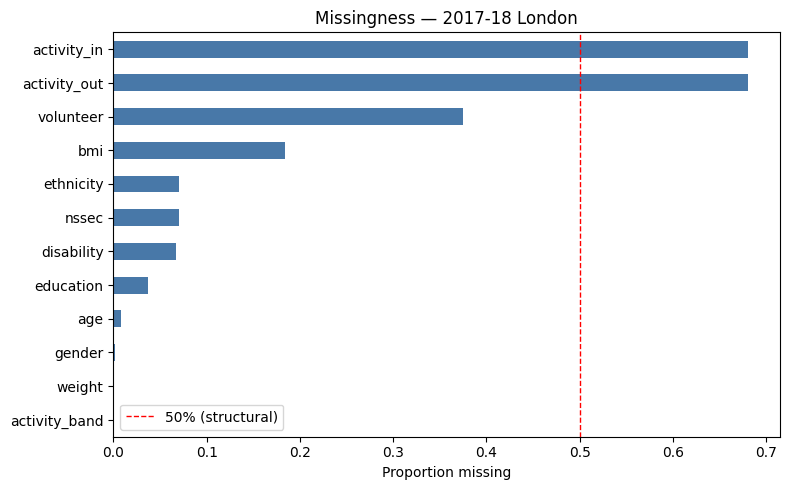

In [6]:
concept_cols = ["activity_band","activity_in","activity_out","age","gender","ethnicity",
                "disability","nssec","education","bmi","volunteer","weight"]   # no health this wave
miss = london[concept_cols].isna().mean().sort_values(ascending=False)
print(miss.round(3).to_string())

fig, ax = plt.subplots(figsize=(8,5))
miss.sort_values().plot(kind="barh", ax=ax, color="#4878a8")
ax.axvline(0.5, color="red", ls="--", lw=1, label="50% (structural)")
ax.set_xlabel("Proportion missing"); ax.set_title("Missingness — 2017-18 London")
ax.legend(); plt.tight_layout(); plt.show()

In [7]:
def check_routing(df, gate_col, gate_value, dependent_cols, label=""):
    """Among rows where gate_col==gate_value, how complete are the dependents?
    ~0% missing = clean universal routing; high+uniform = rotation subsample."""
    cols = [c for c in dependent_cols if c in df.columns]
    if not cols:
        print(f"{label or gate_col}: no dependent columns present"); return
    sub = df[df[gate_col] == gate_value]
    m = sub[cols].isna().mean().round(3)
    all_blank = sub[cols].isna().all(axis=1).sum()
    print(f"{label or gate_col}=={gate_value!r} (n={len(sub)}): "
          f"max dep-missing={m.max():.3f}, all-blank={all_blank} ({all_blank/max(len(sub),1):.1%})")

role_cols = [c for c in london.columns if c.startswith("volint")]
check_routing(london, "volunteer", "Volunteered", role_cols, "Volunteer -> role detail")
disty = [c for c in london.columns if c.startswith("disty")]
check_routing(london, "disability", "Limiting disability", disty, "Limiting disability -> impairment types")

Volunteer -> role detail=='Volunteered' (n=2052): max dep-missing=0.000, all-blank=0 (0.0%)
Limiting disability -> impairment types=='Limiting disability' (n=1922): max dep-missing=0.021, all-blank=41 (2.1%)


## 7. EDA — weight validity & sample composition

Weight: min=0.1494 max=16.80 non-positive=0 missing=0


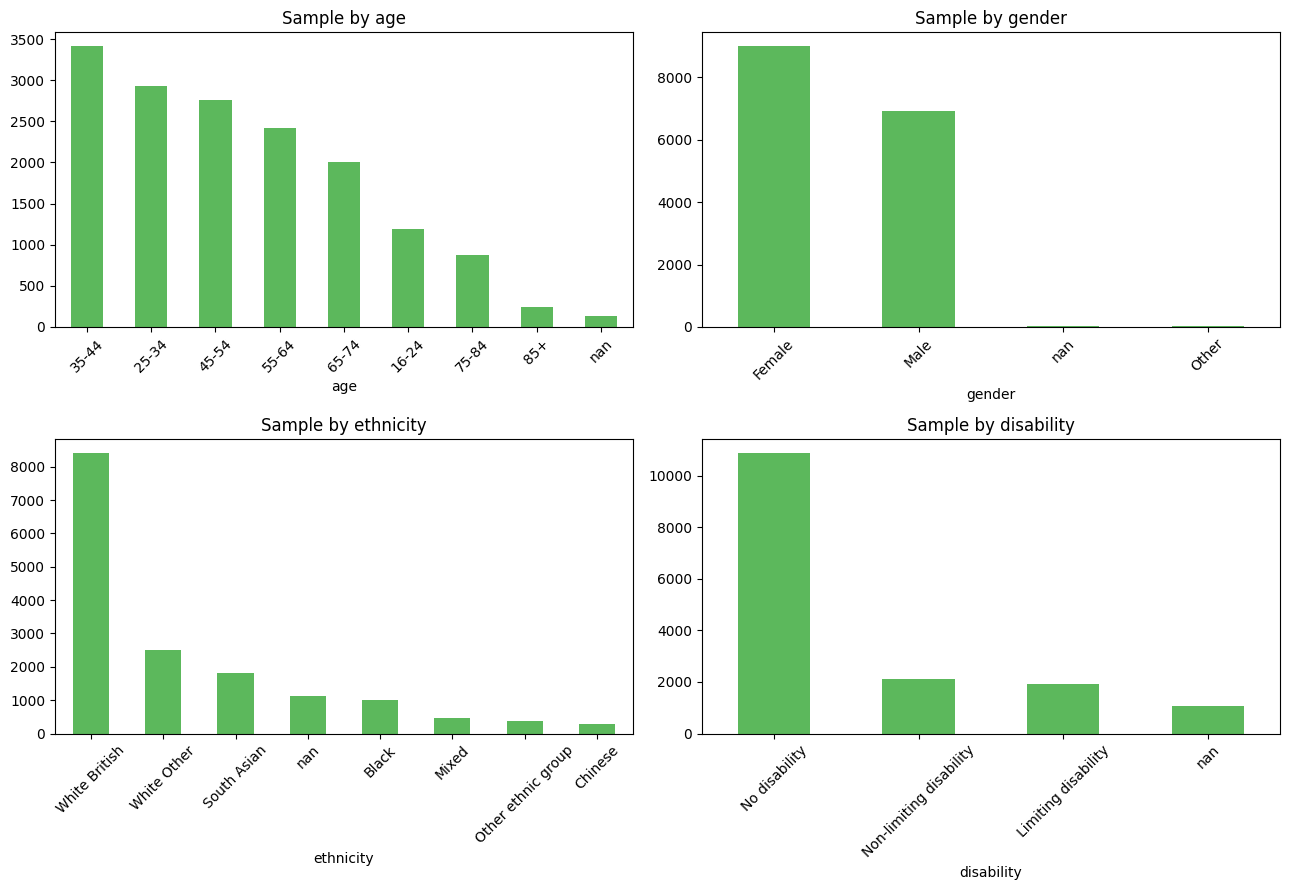

In [8]:
w = london["weight"]
print("Weight: min={:.4f} max={:.2f} non-positive={} missing={}".format(
    w.min(), w.max(), int((w<=0).sum()), int(w.isna().sum())))

fig, axes = plt.subplots(2,2, figsize=(13,9))
for ax, c in zip(axes.ravel(), ["age","gender","ethnicity","disability"]):
    london[c].value_counts(dropna=False).plot(kind="bar", ax=ax, color="#5cb85c")
    ax.set_title(f"Sample by {c}"); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

## 8. Pillar 1 — Participation / activity levels
Overall, by demographic, and **by borough**. Compare overall to 2015-16 London (63.5%).

In [9]:
overall = weighted_share(london, [], "activity_band", "Active")
print(f"Overall London % Active (2017-18): {overall:.3f}   (2015-16 was 0.635)")
for factor in ["age","gender","ethnicity","disability","nssec","education","bmi"]:
    print(f"\n=== % Active by {factor} ===")
    print(weighted_share(london, [factor], "activity_band", "Active").dropna(subset=[factor]).to_string(index=False))

Overall London % Active (2017-18): 0.646   (2015-16 was 0.635)

=== % Active by age ===
  age  weighted_share    n
16-24        0.740734 1195
25-34        0.717785 2929
35-44        0.661760 3412
45-54        0.646888 2758
55-64        0.600132 2417
65-74        0.551180 2001
75-84        0.408252  880
  85+        0.224124  240

=== % Active by gender ===
gender  weighted_share    n
Female        0.622693 8993
  Male        0.671127 6923
 Other        0.755408   16

=== % Active by ethnicity ===
         ethnicity  weighted_share    n
             Black        0.558195 1013
           Chinese        0.660963  272
             Mixed        0.758692  459
Other ethnic group        0.564246  390
       South Asian        0.578925 1805
     White British        0.690475 8413
       White Other        0.685812 2491

=== % Active by disability ===
             disability  weighted_share     n
    Limiting disability        0.457503  1922
          No disability        0.688193 10878
Non-limi

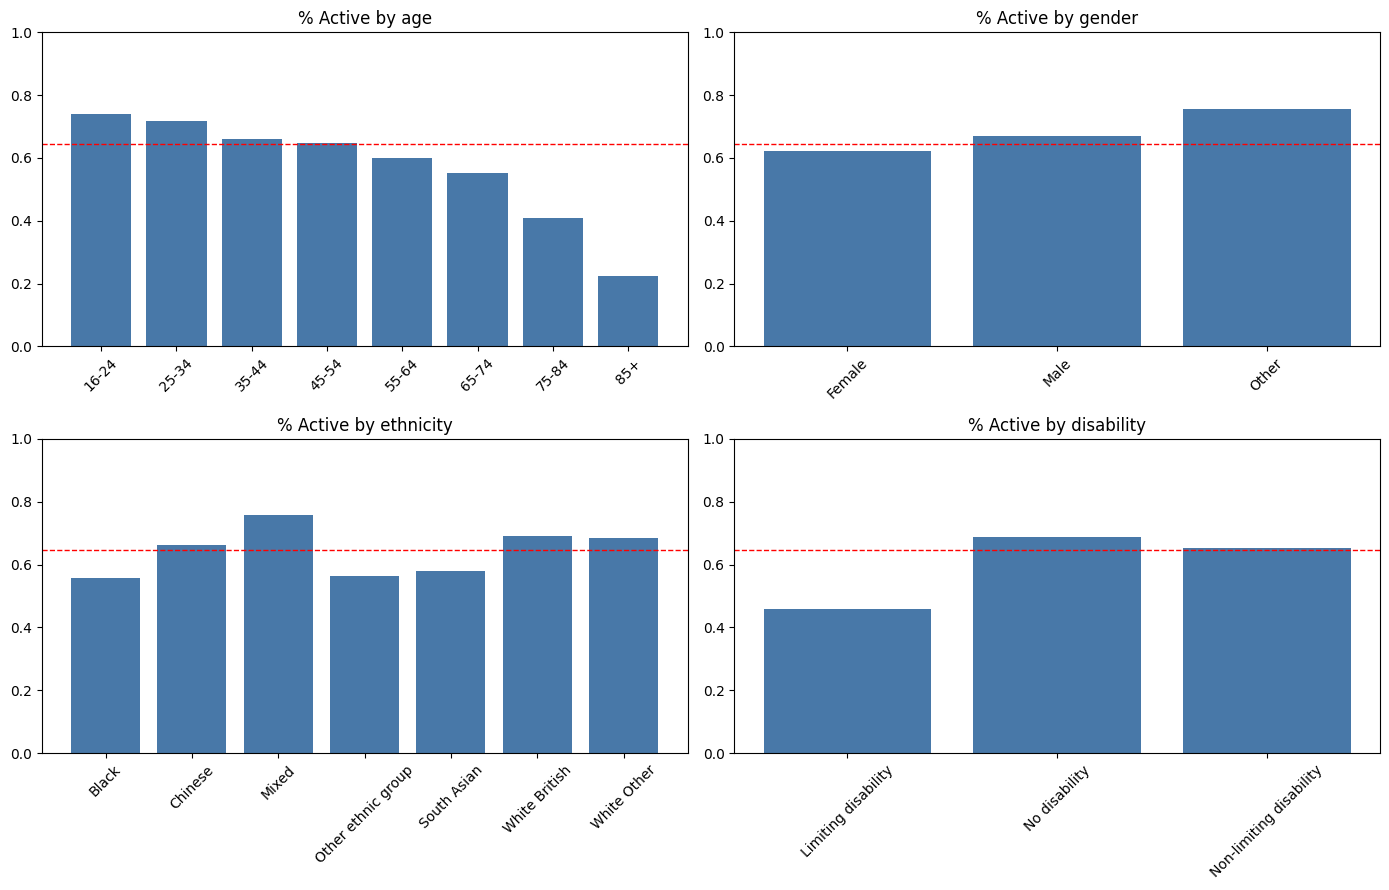

In [10]:
factors = ["age","gender","ethnicity","disability"]
fig, axes = plt.subplots(2,2, figsize=(14,9))
for ax, factor in zip(axes.ravel(), factors):
    res = weighted_share(london, [factor], "activity_band", "Active").dropna(subset=[factor])
    ax.bar(res[factor].astype(str), res["weighted_share"], color="#4878a8")
    ax.axhline(overall, color="red", ls="--", lw=1); ax.set_ylim(0,1)
    ax.set_title(f"% Active by {factor}"); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

### Pillar 1 — by borough

               LA_name  weighted_share   n
                Newham        0.511155 498
  Barking and Dagenham        0.536369 472
                Sutton        0.541917 500
            Hillingdon        0.557355 500
             Redbridge        0.575501 483
                Harrow        0.577218 510
               Enfield        0.596973 499
                 Brent        0.597569 506
              Hounslow        0.599813 489
              Havering        0.609614 509
        Waltham Forest        0.610702 485
               Croydon        0.629711 498
               Bromley        0.638960 484
                Barnet        0.644905 494
             Greenwich        0.647172 488
                Ealing        0.648609 495
              Haringey        0.652283 502
         Tower Hamlets        0.664170 522
Hammersmith and Fulham        0.671160 489
  Kingston upon Thames        0.678730 480
              Lewisham        0.685509 480
                Merton        0.688382 495
           

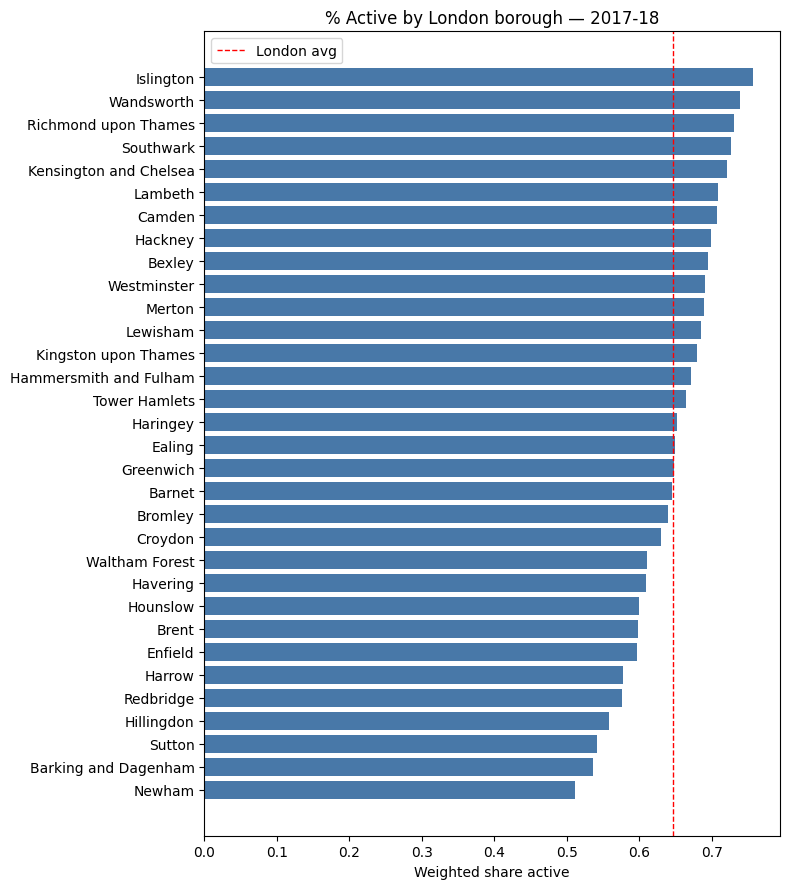

In [11]:
bor = weighted_share(london, ["LA_name"], "activity_band", "Active").sort_values("weighted_share")
print(bor.to_string(index=False))

fig, ax = plt.subplots(figsize=(8,9))
ax.barh(bor["LA_name"], bor["weighted_share"], color="#4878a8")
ax.axvline(overall, color="red", ls="--", lw=1, label="London avg")
ax.set_xlabel("Weighted share active"); ax.set_title("% Active by London borough — 2017-18")
ax.legend(); plt.tight_layout(); plt.show()

## 9. Pillar 2 — Demographics: relationships between variables
Cramér's V measures how strongly two categorical factors move together (0=independent,
1=perfectly associated). `health` is absent this wave, so it is not included.

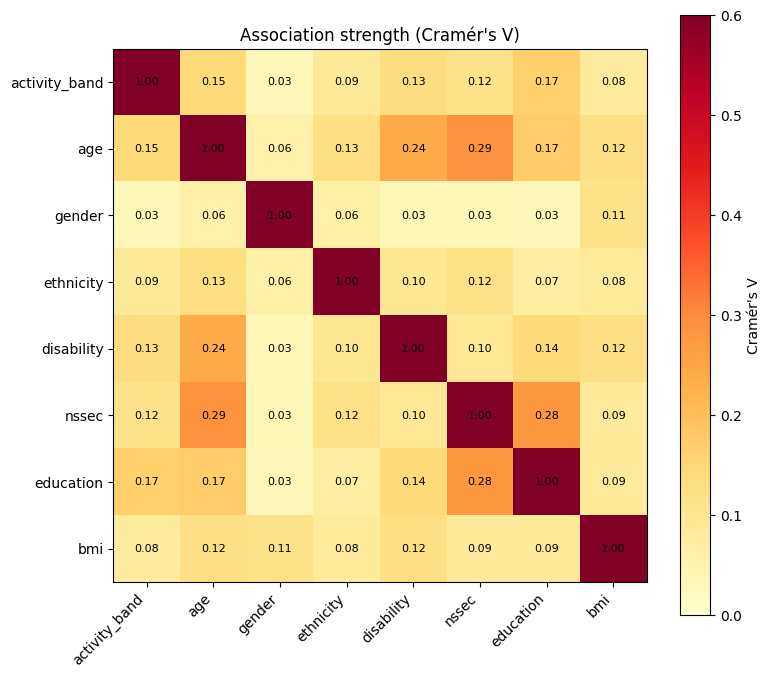

In [12]:
from itertools import combinations
from scipy.stats import chi2_contingency
assoc = ["activity_band","age","gender","ethnicity","disability","nssec","education","bmi"]  # no health

def cramers_v(a, b, df):
    t = pd.crosstab(df[a], df[b])
    if t.shape[0] < 2 or t.shape[1] < 2: return np.nan
    chi2 = chi2_contingency(t)[0]; n = t.values.sum(); r, k = t.shape
    return np.sqrt((chi2/n) / (min(r-1, k-1)))

M = pd.DataFrame(np.eye(len(assoc)), index=assoc, columns=assoc)
for a, b in combinations(assoc, 2):
    v = cramers_v(a, b, london); M.loc[a,b] = M.loc[b,a] = v

fig, ax = plt.subplots(figsize=(8,7))
im = ax.imshow(M.values, cmap="YlOrRd", vmin=0, vmax=0.6)
ax.set_xticks(range(len(assoc))); ax.set_xticklabels(assoc, rotation=45, ha="right")
ax.set_yticks(range(len(assoc))); ax.set_yticklabels(assoc)
for i in range(len(assoc)):
    for j in range(len(assoc)):
        ax.text(j, i, f"{M.values[i,j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Association strength (Cramér's V)")
fig.colorbar(im, label="Cramér's V"); plt.tight_layout(); plt.show()

## 10. Pillar 3 — Indoor vs Outdoor
`MEMS7GR_IN/OUT_*` are **rotation-subgroup** questions — only 31.9% of respondents were asked.
Smaller base, so treat as **indicative**, not headline.

Indoor/outdoor base: 5,099 of 15,967 (31.9%)
Indoor: weighted % active = 0.293
Outdoor: weighted % active = 0.562

% Active indoor vs outdoor by ethnicity:
place               Indoor  Outdoor
ethnicity                          
Black                0.338    0.447
Chinese              0.248    0.519
Mixed                0.370    0.555
Other ethnic group   0.232    0.419
South Asian          0.258    0.496
White British        0.302    0.643
White Other          0.297    0.584


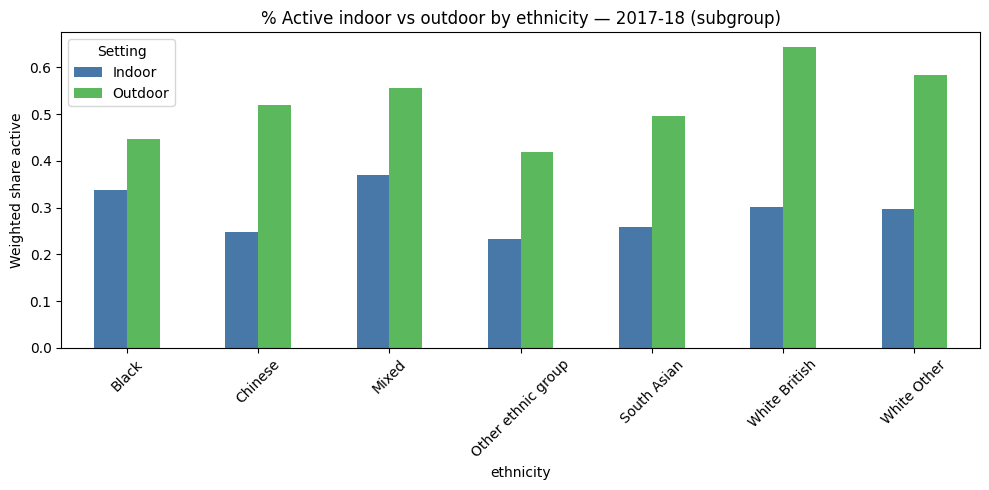

In [13]:
io = london.dropna(subset=["activity_in","activity_out","weight"]).copy()
print(f"Indoor/outdoor base: {len(io):,} of {len(london):,} ({len(io)/len(london):.1%})")
for place, col in [("Indoor","activity_in"), ("Outdoor","activity_out")]:
    print(f"{place}: weighted % active = {weighted_share(io, [], col, 'Active'):.3f}")

rows = []
for col, place in [("activity_in","Indoor"), ("activity_out","Outdoor")]:
    r = weighted_share(io, ["ethnicity"], col, "Active").dropna(subset=["ethnicity"]); r["place"] = place; rows.append(r)
pivot = pd.concat(rows).pivot(index="ethnicity", columns="place", values="weighted_share")
print("\n% Active indoor vs outdoor by ethnicity:"); print(pivot.round(3).to_string())
pivot.plot(kind="bar", figsize=(10,5), color=["#4878a8","#5cb85c"])
plt.title("% Active indoor vs outdoor by ethnicity — 2017-18 (subgroup)")
plt.ylabel("Weighted share active"); plt.xticks(rotation=45); plt.legend(title="Setting")
plt.tight_layout(); plt.show()

### Pillar 3 — indoor vs outdoor by borough (subgroup — small n, indicative)

In [14]:
rows = []
for col, place in [("activity_in","Indoor"), ("activity_out","Outdoor")]:
    r = weighted_share(io, ["LA_name"], col, "Active").dropna(subset=["LA_name"]); r["place"] = place; rows.append(r)
bor_io = pd.concat(rows).pivot(index="LA_name", columns="place", values="weighted_share")
print(bor_io.round(3).to_string())

place                   Indoor  Outdoor
LA_name                                
Barking and Dagenham     0.225    0.419
Barnet                   0.312    0.508
Bexley                   0.273    0.625
Brent                    0.353    0.504
Bromley                  0.174    0.542
Camden                   0.309    0.644
Croydon                  0.224    0.599
Ealing                   0.267    0.652
Enfield                  0.265    0.563
Greenwich                0.330    0.567
Hackney                  0.334    0.531
Hammersmith and Fulham   0.341    0.519
Haringey                 0.350    0.532
Harrow                   0.200    0.474
Havering                 0.306    0.444
Hillingdon               0.209    0.444
Hounslow                 0.210    0.481
Islington                0.399    0.641
Kensington and Chelsea   0.311    0.659
Kingston upon Thames     0.263    0.706
Lambeth                  0.354    0.647
Lewisham                 0.273    0.657
Merton                   0.372    0.534


## 11. Pillar 4 — Volunteering
`VolAny` is coded **0/1** in this wave (decoded above to match the `"Volunteered"` target used by
the other waves). 62.6% non-null.

In [15]:
volr = weighted_share(london, [], "volunteer", "Volunteered")
print(f"Overall weighted % volunteered: {volr:.3f}")
print("volunteer value counts:", london["volunteer"].value_counts(dropna=False).to_dict())
for factor in ["age","gender","disability","nssec"]:
    print(f"\n=== % Volunteered by {factor} ===")
    print(weighted_share(london, [factor], "volunteer", "Volunteered").dropna(subset=[factor]).to_string(index=False))

Overall weighted % volunteered: 0.218
volunteer value counts: {'Not volunteered': 7936, nan: 5979, 'Volunteered': 2052}

=== % Volunteered by age ===
  age  weighted_share    n
16-24        0.330276  715
25-34        0.202077 1697
35-44        0.208199 2088
45-54        0.247567 1729
55-64        0.191380 1571
65-74        0.158418 1326
75-84        0.174941  612
  85+        0.104281  175

=== % Volunteered by gender ===
gender  weighted_share    n
Female        0.186495 5667
  Male        0.252371 4289
 Other        0.159421   15

=== % Volunteered by disability ===
             disability  weighted_share    n
    Limiting disability        0.135073 1276
          No disability        0.237964 6631
Non-limiting disability        0.223181 1421

=== % Volunteered by nssec ===
                            nssec  weighted_share    n
Higher social groups (NS-SEC 1-2)        0.243158 5655
 Lower social groups (NS-SEC 6-8)        0.150125  871
Middle social groups (NS-SEC 3-5)        0.19182

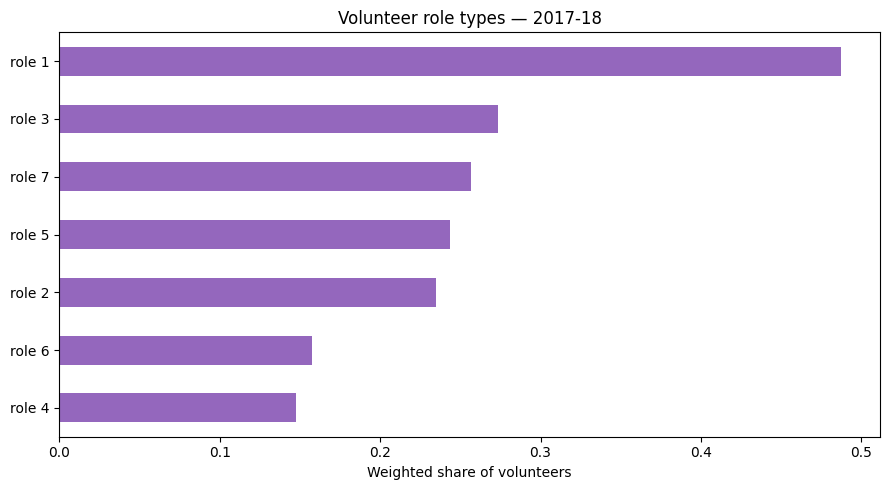

role 4    0.148
role 6    0.158
role 2    0.235
role 5    0.243
role 7    0.257
role 3    0.273
role 1    0.487


In [16]:
vols = london[london["volunteer"] == "Volunteered"].dropna(subset=["weight"]).copy()
role_share = {}
for col, label in VOL_ROLES.items():
    if col in vols.columns:
        d = vols.dropna(subset=[col])
        if len(d):
            role_share[label] = (d[col] * d["weight"]).sum() / d["weight"].sum()

if role_share:
    rs = pd.Series(role_share).sort_values()
    fig, ax = plt.subplots(figsize=(9,5))
    rs.plot(kind="barh", ax=ax, color="#9467bd")
    ax.set_xlabel("Weighted share of volunteers"); ax.set_title("Volunteer role types — 2017-18")
    plt.tight_layout(); plt.show()
    print(rs.round(3).to_string())
else:
    print("No volint*_vol role columns present in this wave — headline VolAny only.")

### Pillar 4 — volunteering rate by borough

In [17]:
vbor = weighted_share(london, ["LA_name"], "volunteer", "Volunteered").sort_values("weighted_share")
print(vbor.to_string(index=False))

               LA_name  weighted_share   n
  Barking and Dagenham        0.148404 274
           Westminster        0.163227 332
                Camden        0.165936 334
             Southwark        0.167669 321
         Tower Hamlets        0.190856 306
              Haringey        0.195542 290
                Newham        0.195698 300
                Sutton        0.197472 318
            Hillingdon        0.198459 313
        Waltham Forest        0.201297 289
                Harrow        0.204911 326
               Hackney        0.206280 325
Hammersmith and Fulham        0.208274 312
              Havering        0.209906 321
              Hounslow        0.210074 314
              Lewisham        0.210951 296
                Merton        0.213603 315
                 Brent        0.214878 307
               Enfield        0.215090 309
Kensington and Chelsea        0.217576 343
            Wandsworth        0.230706 330
  Richmond upon Thames        0.236913 324
           

## 12. Weighted regression — drivers of being active (adjusted)
`health` is **absent** from this wave, so it is dropped (as in 2015-16 / 2016-17).
**Caveat:** `freq_weights` treats survey weights as frequencies, so p-values and confidence
intervals are unreliable — read the odds ratios as directional, not inferential.

In [18]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

m = london.dropna(subset=["activity_band","age","gender","disability",
                          "ethnicity","nssec","weight"]).copy()   # no health this wave
m["active"] = (m["activity_band"] == "Active").astype(int)
print(f"Regression complete-case sample: {len(m):,} of {len(london):,} "
      f"({len(m)/len(london):.0%}) — {len(london)-len(m):,} rows dropped for missing predictors. "
      f"Complete-case deletion may bias estimates if missingness is non-random.")

model = smf.glm(
    'active ~ C(age) '
    '+ C(gender, Treatment(reference="Female")) '
    '+ C(disability, Treatment(reference="No disability")) '
    '+ C(ethnicity, Treatment(reference="White British")) '
    '+ C(nssec)',
    data=m, family=sm.families.Binomial(), freq_weights=m["weight"]).fit()
print(model.summary())

Regression complete-case sample: 13,087 of 15,967 (82%) — 2,880 rows dropped for missing predictors. Complete-case deletion may bias estimates if missingness is non-random.
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 active   No. Observations:                13087
Model:                            GLM   Df Residuals:                 23177.47
Model Family:                Binomial   Df Model:                           18
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -13780.
Date:                Mon, 13 Jul 2026   Deviance:                       27560.
Time:                        13:10:40   Pearson chi2:                 2.32e+04
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1088
Covariance Type:            nonrobust                                         
                                     

In [19]:
or_table = pd.DataFrame({
    "odds_ratio": np.exp(model.params), "p_value": model.pvalues,
    "ci_low": np.exp(model.conf_int()[0]), "ci_high": np.exp(model.conf_int()[1]),
}).round(3)
print(or_table.to_string())

                                                                                odds_ratio  p_value  ci_low  ci_high
Intercept                                                                            6.540    0.000   5.782    7.398
C(age)[T.25-34]                                                                      0.685    0.000   0.610    0.769
C(age)[T.35-44]                                                                      0.559    0.000   0.496    0.630
C(age)[T.45-54]                                                                      0.540    0.000   0.477    0.610
C(age)[T.55-64]                                                                      0.410    0.000   0.360    0.468
C(age)[T.65-74]                                                                      0.299    0.000   0.260    0.344
C(gender, Treatment(reference="Female"))[T.Male]                                     1.153    0.000   1.088    1.221
C(gender, Treatment(reference="Female"))[T.Other]               

## 13. Save cleaned data & wave comparison

In [20]:
london.to_parquet("london_2017_18_clean.parquet")
print("saved london_2017_18_clean.parquet", london.shape)
print("gss present:", "gss" in london.columns, "| non-null:", london["gss"].notna().sum())

# Live comparison across every wave parquet present in the folder
import os
PARQUETS = {
    "2015-16": "london_2015_16_clean.parquet",
    "2016-17": "london_2016_17_clean.parquet",
    "2017-18": "london_2017_18_clean.parquet",
    "2019-20": "london_2019_20_clean.parquet",
    "2021-22": "london_2021_22_clean.parquet",
    "2022-23": "london_2022_23_clean.parquet",
}
rows = []
for wv, p in PARQUETS.items():
    if os.path.exists(p):
        d = pd.read_parquet(p)
        rows.append({"wave": wv, "overall_pct_active": round(weighted_share(d, [], "activity_band", "Active"), 4)})
print(pd.DataFrame(rows).to_string(index=False))

saved london_2017_18_clean.parquet (15967, 542)
gss present: True | non-null: 15967
   wave  overall_pct_active
2015-16              0.6347
2016-17              0.6228
2017-18              0.6461
2019-20              0.6227
2021-22              0.6427
2022-23              0.6434


## Findings — to complete after running

- **Verification:** borough map PROVEN OK from this wave's `.sav`; **4 codes swapped vs shared map**
  (8⇉9 Barnet/Barking, 138⇉139 K&C/Islington) — handled by using the wave-specific map.
- **Overall active rate 2017-18:** ___ % (vs 63.5% in 2015-16).
- **Borough range:** highest ___ , lowest ___ (mind sample sizes via `n`).
- **Indoor vs outdoor:** ___ (31.9% subgroup base — indicative only).
- **Volunteering:** ___ % overall.
- **Regression:** strongest adjusted drivers of being active ___ .
